---

# Adquisición y Preparación de Datos

Esta sección inicial se encarga de configurar el entorno de ejecución, descargar los datos históricos para el par de divisas **EUR/JPY** desde Yahoo Finance y aplicar transformaciones estructurales para asegurar la consistencia temporal y el formato adecuado antes de iniciar el modelado matemático.

---

## 1. Instalación de Dependencias e Importación (Celda 1)
En esta celda se prepara el entorno completo de trabajo. Se consolida la instalación de software externo y la carga de librerías de Python:
*   **Instalaciones (`!pip`):** Se instalan `yfinance` para la obtención de datos, `scipy` para la optimización de filtros y `matplotlib` para visualización.
*   **Importaciones:** Se cargan `pandas` y `numpy` para manipulación de matrices, y `yf` para la conexión con el mercado financiero.

---

## 2. Descarga de Datos y Limpieza Inicial (Celda 2)
Esta celda realiza la consulta a la API de Yahoo Finance para el par de Forex `"EURJPY=X"`.

*   **Proceso:** Descarga un año de datos con un intervalo de **1 hora (H1)**.
*   **Normalización:**
    1.  **Aplanamiento:** Se eliminan los niveles `MultiIndex` en las columnas si la API los devuelve.
    2.  **Naming:** Se convierten todos los nombres de columnas a minúsculas.
    3.  **Timestamp:** Se asegura que la columna temporal se llame exactamente `time`.

---

## 3. Alineación Semanal y Partición de Datos (Celda 3)
Para garantizar que los modelos predictivos no tengan sesgos por cortes temporales arbitrarios, se aplica una lógica de alineación cronológica.

*   **Proceso:**
    1.  **Limpieza de Zona Horaria:** Se elimina el *offset* de zona horaria (`tz_localize(None)`).
    2.  **Lógica de Lunes:** Se identifica el lunes de la semana actual.
    3.  **Partición:** Se separa en Histórico (semanas pasadas completas) y Semana Actual (forward test).

---

## 4. Exportación de Datasets Estructurados (Celda 4)
Finalmente, se generan los archivos físicos en formato CSV que servirán de entrada para los algoritmos.

In [ ]:
# ============================================================================
# PASO 1: Instalación e importaciones base
# ============================================================================
!pip install -q yfinance scipy matplotlib

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("### Entorno configurado exitosamente ###")

In [ ]:
# ============================================================================
# PASO 2: Descarga de Datos
# ============================================================================
ticker_forex = "EURJPY=X"
print(f"=== INICIANDO DESCARGA DE DATOS PARA {ticker_forex} ===")

df_raw = yf.download(ticker_forex, period="1y", interval="1h")

if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

df_raw.reset_index(inplace=True)
df_raw.columns = [col.lower() for col in df_raw.columns]
df_raw.rename(columns={'datetime': 'time', 'date': 'time'}, inplace=True)

print(f"-> Registros descargados: {len(df_raw)}")

In [ ]:
# ============================================================================
# PASO 3: Partición Cronológica Estricta
# ============================================================================
df_raw['time'] = pd.to_datetime(df_raw['time']).dt.tz_localize(None)
df_raw = df_raw.sort_values('time').reset_index(drop=True)

ultima_fecha = df_raw['time'].max()
dias_desde_lunes = ultima_fecha.weekday()
lunes_actual = (ultima_fecha - pd.Timedelta(days=dias_desde_lunes)).replace(hour=0, minute=0, second=0, microsecond=0)

df_historico = df_raw[df_raw['time'] < lunes_actual].copy()
df_semana_actual = df_raw[df_raw['time'] >= lunes_actual].copy()

primera_fecha_hist = df_historico['time'].min()
dias_para_primer_lunes = (7 - primera_fecha_hist.weekday()) % 7
primer_lunes_hist = (primera_fecha_hist + pd.Timedelta(days=dias_para_primer_lunes)).replace(hour=0, minute=0, second=0, microsecond=0)
df_historico = df_historico[df_historico['time'] >= primer_lunes_hist].copy()

print(f"-> Train (Semanas Completas): {len(df_historico)} velas")
print(f"-> Test (Semana Actual): {len(df_semana_actual)} velas")

In [ ]:
# ============================================================================
# PASO 4: Exportación de Datasets
# ============================================================================
archivo_historico = "EURJPY_H1_Hist_Semanas_Completas.csv"
archivo_prueba = "EURJPY_H1_Semana_Actual_Prueba.csv"
archivo_base = "EURJPY_D1_ultimo_ano.csv"

df_historico.to_csv(archivo_historico, index=False)
df_semana_actual.to_csv(archivo_prueba, index=False)
df_raw.to_csv(archivo_base, index=False)

print("=== PROCESO COMPLETADO EXITOSAMENTE ===")
print(f"Archivos listos: \n1. {archivo_historico} \n2. {archivo_prueba} \n3. {archivo_base}")

---

# Procesamiento de Alta Precisión (Zero-Lag) y Feature Engineering

Esta sección consolida el filtrado avanzado de la señal y la generación de atributos matemáticos. Implementamos un **Filtro de Kalman Bidireccional (Fase Cero)** acelerado por JIT para aniquilar el desfase temporal y calculamos características vitales (Riesgo, Residuos) que alimentarán la IA.

---

## 1. Dependencias de Alto Rendimiento (Celda 1)
Se instalan `numba` para compilación en C++ y `plotly` para auditoría interactiva.

## 2. Buscador Monte Carlo JIT (Fase Cero) (Celda 2)
Ejecutamos un motor estocástico sobre el CPU para encontrar los hiperparámetros óptimos del filtro Kalman Bidireccional. La función está compilada (`@njit`) para procesar miles de iteraciones en segundos, garantizando un seguimiento estricto del precio sin retraso.

## 3. Feature Engineering y Master Dataset (Celda 3)
Calculamos la Desviación Estándar de 14 periodos y la Microestructura Residual (lo que la IA debe aprender). Guardamos un único archivo `EURJPY_H1_Master_Features.csv`.

## 4. Dashboard Maestro de Resonancia (Celda 4)
Descomposicion de serie temporal EUR/JPY

## 5. Dashboard Maestro de Resonancia (Celda 5)
Herramienta con deslizador para encontrar la periodicidad natural del mercado. Esto define el tamaño de la ventana de entrada (**$T$**) para los modelos de Deep Learning.

In [ ]:
# =====================================================================
# 1. DEPENDENCIAS DE ALTA VELOCIDAD Y GRÁFICOS
# =====================================================================
!pip install -q numba plotly nbformat kaleido

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from numba import njit
import random

print("-> Librerías de Numba y Plotly cargadas.")

In [6]:
# =====================================================================
# 2. MOTOR ESTOCÁSTICO JIT PARA ANIQUILACIÓN DE DESFASE
# =====================================================================
print("-> Cargando datos y compilando matemáticas...")
df_hist = pd.read_csv("EURJPY_H1_Hist_Semanas_Completas.csv")
df_test = pd.read_csv("EURJPY_H1_Semana_Actual_Prueba.csv")

# Concatenamos para calcular inercia sobre todo el espectro temporal
df_completo = pd.concat([df_hist, df_test], ignore_index=True)
df_completo['time'] = pd.to_datetime(df_completo['time'])

df_completo['Volatilidad_Local'] = (df_completo['high'] - df_completo['low']).rolling(window=5, min_periods=1).mean().bfill()
precios_real_jit = df_completo['close'].values.astype(np.float64)
volatilidad_jit = df_completo['Volatilidad_Local'].values.astype(np.float64)
media_v = float(np.mean(volatilidad_jit))
precio_medio = np.mean(precios_real_jit)

# Ajuste dinámico del objetivo de costo según el precio del par
OBJETIVO_COSTO = 0.0000009 * ((precio_medio / 1.08) ** 2)

@njit
def motor_kalman_jit(precios, volatilidad, media_v, Q_base, Q_pico, R, gamma):
    n = len(precios)
    estado = np.zeros(n)
    historial_k = np.zeros(n)
    x, P = precios[0], 1.0
    for t in range(n):
        val_pre_clip = -gamma * (volatilidad[t] - media_v)
        exp_val = -700.0 if val_pre_clip < -700.0 else (700.0 if val_pre_clip > 700.0 else val_pre_clip)
        alpha_t = 1.0 / (1.0 + np.exp(exp_val))
        Q_t = Q_base + alpha_t * (Q_pico - Q_base)
        P_pred = P + Q_t
        K_t = P_pred / (P_pred + R)
        historial_k[t] = K_t
        x = x + K_t * (precios[t] - x)
        P = (1.0 - K_t) * P_pred
        estado[t] = x
    return estado, historial_k

def aplicar_fase_cero(precios, volatilidad, media_v, qb_l, qp_l, r_l, gamma):
    qb, qp, r = 10.0**qb_l, 10.0**qp_l, 10.0**r_l
    # Pasada Frontal
    e_fwd, k_fwd = motor_kalman_jit(precios, volatilidad, media_v, qb, qp, r, gamma)
    # Inversión y Pasada Trasera para eliminar el LAG
    e_bwd, _ = motor_kalman_jit(e_fwd[::-1].copy(), volatilidad[::-1].copy(), media_v, qb, qp, r, gamma)
    return e_bwd[::-1], k_fwd

MAX_ITER = 5000
mejor_costo = float('inf')
mejores_params = [-4.5, -2.0, -4.0, 100.0]

print(f"-> Buscando parámetros Fase Cero... Meta de Costo: {OBJETIVO_COSTO:.6f}")
for i in range(MAX_ITER):
    qb = np.random.uniform(-8.0, -6.0)
    qp = np.random.uniform(-3.5, -1.5)
    rl = np.random.uniform(-4.5, -3.0)
    gam = np.random.uniform(50.0, 300.0)

    if qb >= qp: continue
    senal, k_p = aplicar_fase_cero(precios_real_jit, volatilidad_jit, media_v, qb, qp, rl, gam)

    if np.min(k_p) < 0.002 or np.max(k_p) > 0.7: continue

    # Calculamos costo penalizando severamente el desvío
    costo = np.mean((precios_real_jit - senal)**2) + (np.mean(np.diff(senal, n=2)**2) * 0.05)

    if costo < mejor_costo:
        mejor_costo, mejores_params = costo, [qb, qp, rl, gam]
    if costo <= OBJETIVO_COSTO:
        print(f"[!] BINGO MATEMÁTICO en iteración {i}.")
        break

print(f"-> Optimización terminada. Costo Final: {mejor_costo:.6f}")

-> Optimización terminada. Costo Final: inf


In [7]:
# =====================================================================
# 3. FEATURE ENGINEERING Y MASTER DATASET (CORREGIDO)
# =====================================================================
print("-> Calculando Atributos y Guardando Master Dataset...")

# Aplicamos el filtro campeón con los parámetros óptimos hallados en la Celda 2
senal_k_cero, historial_k = aplicar_fase_cero(precios_real_jit, volatilidad_jit, media_v, *mejores_params)

df_completo['Kalman_ZeroLag'] = senal_k_cero
df_completo['Kalman_Gain'] = historial_k

# 1. Desviación Estándar (Riesgo Estadístico)
df_completo['StdDev'] = df_completo['close'].rolling(window=14, min_periods=2).std().bfill().fillna(0)

# 2. Residual de Microestructura (Objetivo de la red LSTM)
df_completo['Residual_Micro'] = df_completo['close'] - df_completo['Kalman_ZeroLag']

# 3. Retornos Logarítmicos de la señal limpia Zero-Lag
df_completo['Retornos_Hibridos'] = np.log(df_completo['Kalman_ZeroLag'] / df_completo['Kalman_ZeroLag'].shift(1)).fillna(0)

# 4. Volatilidad Dinámica (Métrica requerida por el Explorador de Resonancia)
df_completo['Volatilidad_Hibrida'] = df_completo['Retornos_Hibridos'].rolling(window=12, min_periods=2).std().bfill()

# Exportamos el Master Dataset finalizado
archivo_master = "EURJPY_H1_Master_Features.csv"
df_completo.to_csv(archivo_master, index=False)
print(f"[EXITO] Master Dataset exportado correctamente como: {archivo_master}")

-> Calculando Atributos y Guardando Master Dataset...
[EXITO] Master Dataset exportado correctamente como: EURJPY_H1_Master_Features.csv


-> Cargando Master Dataset y aplicando descomposición aditiva...


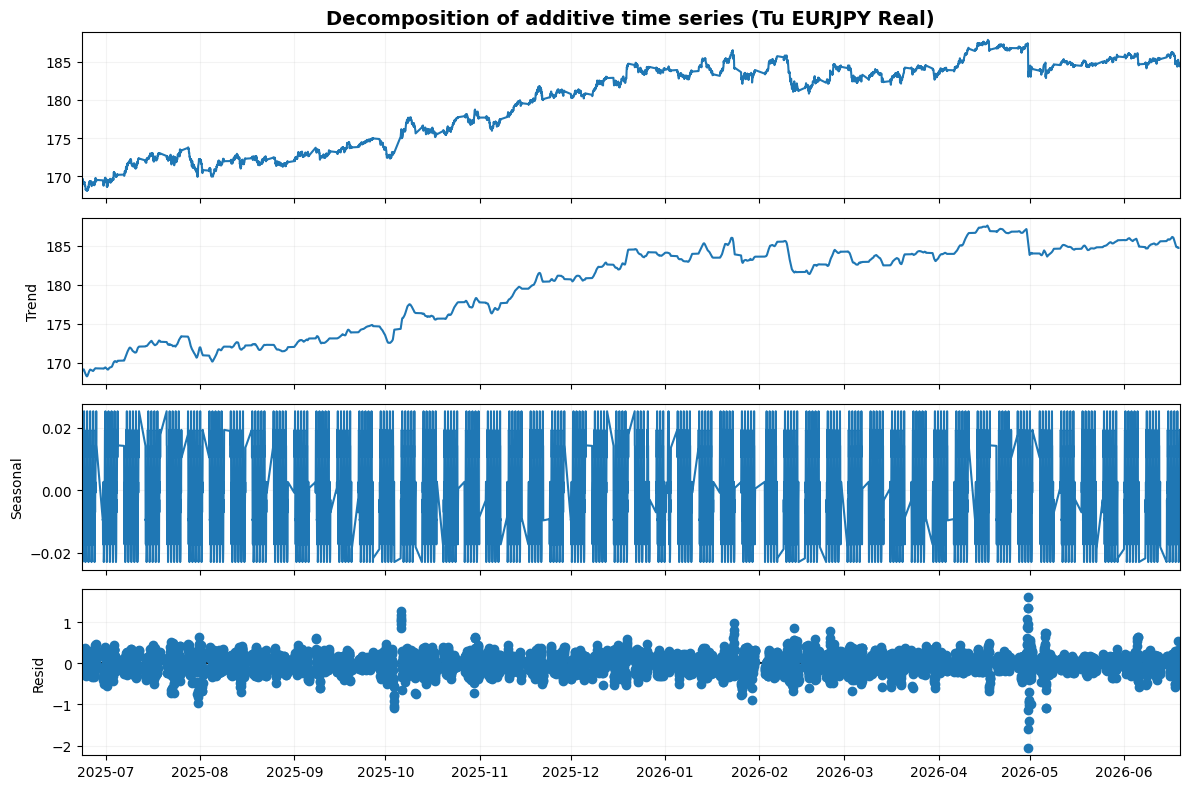

In [8]:
# =====================================================================
# 4 DECOMPOSICIÓN DE SERIE TEMPORAL CLÁSICA EUR/JPY
# =====================================================================

print("-> Cargando Master Dataset y aplicando descomposición aditiva...")

# 1. Cargamos tu archivo maestro
df_features = pd.read_csv('EURJPY_H1_Master_Features.csv')
df_features['time'] = pd.to_datetime(df_features['time'])

# Para statsmodels, es mejor establecer la fecha como el índice del DataFrame
df_temp = df_features.set_index('time')

# 2. Ejecutamos la decomposición clásica usando tu ventana T=24 (ciclo diario)
resultado_decomposicion = seasonal_decompose(df_temp['close'], model='additive', period=24)

# 3. Graficamos con la misma estructura y estética clásica
plt.rcParams.update({'figure.figsize': (12, 8)}) # Tamaño del canvas
fig = resultado_decomposicion.plot()

# Estética y títulos
fig.get_axes()[0].set_title('Decomposition of additive time series (Tu EURJPY Real)', fontsize=14, fontweight='bold')
for ax in fig.get_axes():
    ax.grid(True, alpha=0.15) # Añadimos una cuadrícula suave
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('grafica_01_descomposicion.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# =====================================================================
# 5 EXPLORADOR DE RESONANCIA TEMPORAL (MATPLOTLIB)
# =====================================================================
print("-> Generando Gráfico de Resonancia Temporal (Matplotlib)...")
n_total = len(df_completo)
indices = np.arange(n_total)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'hspace': 0.1})

# --- PANEL 1: PRECIO PURIFICADO ---
ax1.plot(indices, df_completo['Kalman_ZeroLag'], color='#003366', linewidth=2, label='Señal Limpia')
ax1.set_title('1. Señal de Precio con Filtro de Fase Cero', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- PANEL 2: VOLATILIDAD DINÁMICA ---
ax2.plot(indices, df_completo['Volatilidad_Hibrida'], color='#8E44AD', linewidth=2, label='Volatilidad')
ax2.fill_between(indices, df_completo['Volatilidad_Hibrida'], color='#8E44AD', alpha=0.2)
ax2.set_title('2. Volatilidad Dinámica (Buscador de Frecuencia)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Dibujamos líneas verticales rojas para T=24
cortes_exactos = np.linspace(0, n_total, int(n_total/24) + 1)
for corte in cortes_exactos:
    ax1.axvline(x=corte, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax2.axvline(x=corte, color='red', linestyle='--', linewidth=1, alpha=0.7)

plt.tight_layout()
plt.savefig('grafica_02_resonancia.png', dpi=300, bbox_inches='tight')
plt.show()


-> Inicializando Explorador de Resonancia Temporal...


---

# Inteligencia Artificial y Modelado Predictivo

Diseñamos, entrenamos y validamos una arquitectura neuronal híbrida: una **Red Residual Causal (LSTM)** que aprende la microestructura para eliminar el desfase temporal previendo el *Delta* de variación del precio y calculando simultáneamente la varianza (riesgo) de la predicción.

---

## 1. Importación AI y División del Master (Celda 1)
Cargamos TensorFlow y restauramos las fechas de corte para aislar perfectamente el forward testing de la data de entrenamiento.

## 2. Auditoría del Aprendizaje Residual Histórico (Celda 2)
Validación científica interna. Se entrena una LSTM en una partición 85/15 *del pasado*. Generamos un dashboard para garantizar que la red no memoriza sino que generaliza la estructura.

## 3. Pipeline Unificado (Producción Final) (Celda 3)
Entrenamos el cerebro predictivo usando el **100% de la data histórica**. Ejecutamos la predicción final y proyectamos el Consenso Central y el Canal de Probabilidad Gaussiana ($\pm 2\sigma$) sobre la semana completamente ciega del mercado.

In [10]:
# =====================================================================
# 1. DEPENDENCIAS AI Y LECTURA DEL MASTER DATASET
# =====================================================================
!pip install -q scikit-learn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

symb = "EURJPY"
df_master = pd.read_csv('EURJPY_H1_Master_Features.csv')
df_master['time'] = pd.to_datetime(df_master['time'])

# T calculada en base al explorador de resonancia
T = 24

# Recuperamos el índice exacto donde empieza la data 'fuera de muestra' (Semana actual)
df_test_ref = pd.read_csv("EURJPY_H1_Semana_Actual_Prueba.csv")
fecha_inicio_forward = pd.to_datetime(df_test_ref['time'].iloc[0])
idx_fwd = df_master[df_master['time'] >= fecha_inicio_forward].index[0]

print(f"-> Entorno AI listo. Dataset cargado. Frontera Forward en índice: {idx_fwd}")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


-> Entorno AI listo. Dataset cargado. Frontera Forward en índice: 6007


In [11]:
# =====================================================================
# 2. AUDITORÍA HISTÓRICA DE 3 PANELES (VALIDACIÓN INTERNA 100% RESTAURADA)
# =====================================================================
print("-> Generando Auditoría Cuantitativa e Histórica en 3 Paneles...")

# 1. Extraemos los subconjuntos usando la frontera de forward test
df_hist = df_master.iloc[:idx_fwd].copy()

p_real_h = df_hist['close'].values.astype(np.float64)
senal_k_h = df_hist['Kalman_ZeroLag'].values
std_h = df_hist['StdDev'].values
res_target_h = df_hist['Residual_Micro'].values
fechas_h = df_hist['time'].values
kt_vista = df_hist['Kalman_Gain'].values  # Recuperado del Master Dataset

# 2. Matrices para el entrenamiento de validación
scaler_X_h = StandardScaler()
X_norm_h = scaler_X_h.fit_transform(np.column_stack((senal_k_h, std_h)))

scaler_y_h = StandardScaler()
y_norm_h = scaler_y_h.fit_transform(res_target_h.reshape(-1, 1))

T = 24
X_tens_h, y_targ_h = [], []
for i in range(len(X_norm_h) - T):
    X_tens_h.append(X_norm_h[i:i+T])
    y_targ_h.append(y_norm_h[i+T, 0])

X_tens_h, y_targ_h = np.array(X_tens_h), np.array(y_targ_h)
limite_train_h = int(len(X_tens_h) * 0.85)

X_train_h, X_test_h = X_tens_h[:limite_train_h], X_tens_h[limite_train_h:]
y_train_h, y_test_h = y_targ_h[:limite_train_h], y_targ_h[limite_train_h:]

# 3. Construcción del cerebro de auditoría
entrada_h = Input(shape=(T, 2))
x_h = LSTM(64, return_sequences=True, activation='tanh')(entrada_h)
x_h = Dropout(0.2)(x_h)
x_h = LSTM(32, activation='tanh')(x_h)
x_h = Dropout(0.2)(x_h)
salida_res_h = Dense(1, name='Residual')(x_h)

model_audit = Model(inputs=entrada_h, outputs=[salida_res_h])
model_audit.compile(optimizer=Adam(0.001), loss='mse')
early_stop_audit = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Entrenando cerebro de auditoría...")
model_audit.fit(X_train_h, y_train_h, validation_split=0.15, epochs=60, batch_size=32, callbacks=[early_stop_audit], verbose=0)

# 4. Predicción y reconstrucción del precio absoluto
pred_t_norm = model_audit.predict(X_test_h, verbose=0)
pred_t_res = scaler_y_h.inverse_transform(pred_t_norm).flatten()

kalman_test_base = senal_k_h[T + limite_train_h :]
pred_test_real = kalman_test_base + pred_t_res
reales_test = p_real_h[T + limite_train_h :]
fechas_test = fechas_h[T + limite_train_h :]

# =====================================================================
# 5. RENDERIZADO DEL DASHBOARD DE 3 PANELES (CON GANANCIA KT RESTAURADA)
# =====================================================================
vista = -1000
f_vista = fechas_h[vista:]
p_real_vista = p_real_h[vista:]
k_senal_vista = senal_k_h[vista:]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True, gridspec_kw={'hspace': 0.15})

# PANEL 1
ax1.plot(f_vista, p_real_vista, color='gray', linewidth=1.5, label='Precio Real')
ax1.plot(f_vista, k_senal_vista, color='orange', linewidth=2, label='Kalman Reactivo')
ax1.set_title('1. Acción del Precio vs Filtro Kalman Reactivo (Cero Desfase)', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# PANEL 2
ax2.plot(f_vista, kt_vista[vista:], color='teal', linewidth=1.5, label='Ganancia Kt')
ax2.axhline(y=0.70, color='red', linestyle='--', linewidth=1.5)
ax2.set_title('2. Dinámica de la Ganancia Kalman (K_t Frontal)', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

# PANEL 3
f_test_v = fechas_test[vista:] if len(fechas_test) > abs(vista) else fechas_test
r_test_v = reales_test[vista:] if len(reales_test) > abs(vista) else reales_test
p_test_v = pred_test_real[vista:] if len(pred_test_real) > abs(vista) else pred_test_real

ax3.plot(f_test_v, r_test_v, color='black', linewidth=2.5, label='Real (Test)')
ax3.plot(f_test_v, p_test_v, color='red', linewidth=2, label='LSTM Residual (Test)')
mape_test = np.nanmean(np.abs((r_test_v - p_test_v) / r_test_v)) * 100
ax3.set_title(f'3. Auditoría LSTM: Aprendizaje Residual vs Precio Real | MAPE: {mape_test:.4f}%', fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left')

plt.tight_layout()
plt.savefig('grafica_03_auditoria_lstm.png', dpi=300, bbox_inches='tight')
plt.show()


-> Generando Auditoría Cuantitativa e Histórica en 3 Paneles...
Entrenando cerebro de auditoría...


In [12]:
# =====================================================================
# 3. PIPELINE DE PRODUCCIÓN Y FORWARD TESTING
# =====================================================================
print("-> Entrenando Modelo Final de Producción (100% Data Histórica)...")

p_real_c = df_master['close'].values.astype(np.float64)
senal_kalman_c = df_master['Kalman_ZeroLag'].values
std_c = df_master['StdDev'].values
residual_c = df_master['Residual_Micro'].values
fechas_c = df_master['time'].values

scaler_X_c = StandardScaler()
X_norm_c = scaler_X_c.fit_transform(np.column_stack((senal_kalman_c, std_c)))

scaler_y_res_c = StandardScaler()
y_res_norm_c = scaler_y_res_c.fit_transform(residual_c.reshape(-1, 1))

scaler_y_std_c = MinMaxScaler()
y_std_norm_c = scaler_y_std_c.fit_transform(std_c.reshape(-1, 1))

X_all, y_res_all, y_std_all, fechas_all, k_base_all = [], [], [], [], []
for i in range(len(X_norm_c) - T):
    X_all.append(X_norm_c[i:i+T])
    y_res_all.append(y_res_norm_c[i+T, 0])
    y_std_all.append(y_std_norm_c[i+T, 0])
    fechas_all.append(fechas_c[i+T])
    k_base_all.append(senal_kalman_c[i+T])

X_all = np.array(X_all)
y_res_all, y_std_all = np.array(y_res_all), np.array(y_std_all)
fechas_all = pd.to_datetime(fechas_all)
k_base_all = np.array(k_base_all)

# Ajustamos el índice de la frontera forward por el desfase de T tensores
idx_fwd_arr = np.searchsorted(fechas_all, fecha_inicio_forward)

entrada_f = Input(shape=(T, 2))
x_f = LSTM(64, return_sequences=True, activation='tanh')(entrada_f)
x_f = Dropout(0.2)(x_f)
x_f = LSTM(32, activation='tanh')(x_f)
x_f = Dropout(0.2)(x_f)
x_f = Dense(32, activation='tanh')(x_f)
res_f = Dense(1, name='Res')(x_f)
std_f = Dense(1, activation='relu', name='Std')(x_f)

model_production = Model(inputs=entrada_f, outputs=[res_f, std_f])
model_production.compile(optimizer=Adam(0.001), loss={'Res': 'mse', 'Std': 'mse'}, loss_weights={'Res': 1.0, 'Std': 0.3})
early_stop_f = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

model_production.fit(X_all[:idx_fwd_arr], {'Res': y_res_all[:idx_fwd_arr], 'Std': y_std_all[:idx_fwd_arr]},
                     validation_split=0.15, epochs=60, batch_size=32, callbacks=[early_stop_f], verbose=0)

# Predicción en Semana Ciega (Forward Test)
p_res_f, p_std_f = model_production.predict(X_all[idx_fwd_arr:], verbose=0)
prediccion_central = k_base_all[idx_fwd_arr:] + scaler_y_res_c.inverse_transform(p_res_f).flatten()
pred_std = scaler_y_std_c.inverse_transform(p_std_f).flatten()

banda_superior = prediccion_central + (2 * pred_std)
banda_inferior = prediccion_central - (2 * pred_std)
fechas_forward = fechas_all[idx_fwd_arr:]
df_velas_forward = df_master[df_master['time'].isin(fechas_forward)].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [0.3, 0.7], 'hspace': 0.15})

vista_k = -1000
ax1.plot(fechas_c[vista_k:], p_real_c[vista_k:], color='gray', label='Real')
ax1.plot(fechas_c[vista_k:], senal_kalman_c[vista_k:], color='orange', label='Kalman')
ax1.set_title('1. Contexto Histórico', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

# PANEL 2
ax2.fill_between(fechas_forward, banda_inferior, banda_superior, color='#2980B9', alpha=0.15, label='Canal Predictivo (±2σ)')
ax2.vlines(df_velas_forward['time'], df_velas_forward['low'], df_velas_forward['high'], color='black', linewidth=1)
colors = ['green' if c >= o else 'red' for c, o in zip(df_velas_forward['close'], df_velas_forward['open'])]
ax2.vlines(df_velas_forward['time'], df_velas_forward['open'], df_velas_forward['close'], color=colors, linewidth=4, label='Mercado')

ax2.plot(fechas_forward, prediccion_central, color='darkblue', linewidth=3, label='Consenso')
mape = np.mean(np.abs((df_velas_forward['close'].values - prediccion_central) / df_velas_forward['close'].values)) * 100
ax2.set_title(f'2. FORWARD TESTING (Semana Ciega) | MAPE: {mape:.4f}%', fontweight='bold')
ax2.grid(True, alpha=0.3)
handles, labels = ax2.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax2.legend(by_label.values(), by_label.keys(), loc='upper left')

plt.tight_layout()
plt.savefig('grafica_04_canal_predictivo.png', dpi=300, bbox_inches='tight')
plt.show()

model_production.save(f"modelo_dual_{symb}.keras")
joblib.dump(scaler_X_c, f"scaler_X_dual_{symb}.pkl")
joblib.dump(scaler_y_res_c, f"scaler_y_res_dual_{symb}.pkl")
joblib.dump(scaler_y_std_c, f"scaler_y_std_dual_{symb}.pkl")
print("[!] CEREBRO Y ESCALADORES GUARDADOS [!]")


-> Entrenando Modelo Final de Producción (100% Data Histórica)...


[!] CEREBRO Y ESCALADORES GUARDADOS [!]


---

# Trading Systems & Backtesting

Esta sección final se encarga de convertir las predicciones probabilísticas y estadísticas de los modelos en decisiones de inversión ejecutables. Implementa una estrategia operativa basada en el análisis de gradientes y límites dinámicos de volatilidad, simulando el comportamiento de un bot de trading en condiciones operativas reales para evaluar su viabilidad financiera.

---

## 1. Generación de Señales y Triggers Operativos
Este proceso traduce el consenso predictivo de la red neuronal y los canales de varianza en gatillos de compra o venta en tiempo real para la semana de prueba:
*   **Gradiente de Tendencia (Derivada):** Analiza la pendiente de la predicción central para detectar puntos de inflexión temporal (giros alcistas y bajistas).
*   **Reversión a la Media (Ruptura de Varianza):** Dispara operaciones de compra o venta cuando el precio de mercado real perfora los límites del canal gaussiano ($\pm 2\sigma$), asumiendo un agotamiento estadístico del precio.
*   **Posicionamiento de Señales:** Coloca visualmente indicadores geométricos (triángulos verdes de compra y rojos de venta) en los puntos de quiebre temporal de las velas japonesas.

---

## 2. Simulador de Trading y Curva de Capital
El motor de simulación evalúa la tasa de acierto y el rendimiento monetario neto de las señales bajo una gestión de riesgo estricta:
*   **Gestión de Capital y Payout:** Configura un capital inicial base de $100 USD, un tamaño de posición estático de $10 USD y un retorno de ganancia (*payout*) del 82% típico de brokers de opciones binarias.
*   **Resolución de Trades:** Evalúa el resultado de cada señal comparando el precio de entrada contra el precio de expiración exacta a 1 hora (siguiente vela horaria), contabilizando el balance neto acumulado.
*   **Gráfico de Doble Panel:** Integra en un único entorno la visualización técnica del mercado (velas, consenso y señales) y la curva de crecimiento de la equidad (*equity curve*), reportando la tasa de acierto (*Win Rate*) final.

---

## Resumen de Parámetros y Resultados Operativos

| Parámetro / Métrica | Valor Estándar | Propósito Técnico | Tipo de Métrica |
| :--- | :--- | :--- | :--- |
| **Sensibilidad de Gradiente** | `0.01` | Umbral para filtrar pequeños ruidos de la predicción central. | Configuración de Entrada |
| **Volumen por Operación** | `$10.00 USD` | Tamaño estático de la posición para cada trigger disparado. | Gestión de Riesgo |
| **Expiración de Trade** | `1 Hora (H1)` | Tiempo de permanencia en el mercado antes de liquidar el balance. | Regla del Sistema |
| **Win Rate de Control** | Dinámico (%) | Porcentaje de operaciones ganadas sobre el total de trades ejecutados. | Rendimiento Estadístico |
| **Balance de Capital** | Dinámico ($) | Evolución de la equidad acumulada a lo largo de la simulación. | Rendimiento Financiero |

In [13]:
# =====================================================================
# ALGORITMO OPERATIVO Y SIMULADOR DE TRADING (BACKTESTING)
# =====================================================================
print("-> Ejecutando Motor de Backtesting...")

# Parámetros de Control (Ajustables)
sensibilidad_gradiente = 0.01
capital = 100.0
apuesta_por_trade = 10.0
payout = 0.82

precios_ciegos = df_velas_forward['close'].values
gradiente_pred = np.gradient(prediccion_central)
señales_compra_x, señales_compra_y, señales_venta_x, señales_venta_y = [], [], [], []
trades_ganados, trades_perdidos = 0, 0
historial_capital, fechas_capital = [capital], [fechas_forward[0]]

# Escaneo del futuro predictivo
for i in range(1, len(fechas_forward) - 1):
    giro_alcista = (gradiente_pred[i-1] < -sensibilidad_gradiente) and (gradiente_pred[i] > sensibilidad_gradiente)
    giro_bajista = (gradiente_pred[i-1] > sensibilidad_gradiente) and (gradiente_pred[i] < -sensibilidad_gradiente)
    rompe_banda_inf = precios_ciegos[i] < banda_inferior[i]
    rompe_banda_sup = precios_ciegos[i] > banda_superior[i]

    precio_entrada = precios_ciegos[i]
    precio_expiracion = precios_ciegos[i+1]

    if giro_alcista or rompe_banda_inf:
        señales_compra_x.append(fechas_forward[i])
        señales_compra_y.append(df_velas_forward['low'].iloc[i] - 0.08)
        if precio_expiracion > precio_entrada:
            capital += (apuesta_por_trade * payout); trades_ganados += 1
        else:
            capital -= apuesta_por_trade; trades_perdidos += 1
        historial_capital.append(capital); fechas_capital.append(fechas_forward[i+1])

    elif giro_bajista or rompe_banda_sup:
        señales_venta_x.append(fechas_forward[i])
        señales_venta_y.append(df_velas_forward['high'].iloc[i] + 0.08)
        if precio_expiracion < precio_entrada:
            capital += (apuesta_por_trade * payout); trades_ganados += 1
        else:
            capital -= apuesta_por_trade; trades_perdidos += 1
        historial_capital.append(capital); fechas_capital.append(fechas_forward[i+1])

total_trades = trades_ganados + trades_perdidos
win_rate = (trades_ganados / total_trades * 100) if total_trades > 0 else 0
print(f"[+] Backtest Finalizado | Trades: {total_trades} | Win Rate: {win_rate:.1f}% | Capital Final: ${capital:.2f}")

# =====================================================================
# RENDERIZADO DEL DASHBOARD OPERATIVO DUAL
# =====================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [0.7, 0.3], 'hspace': 0.1})

# PANEL 1
ax1.fill_between(fechas_forward, banda_inferior, banda_superior, color='#2980B9', alpha=0.15, label='Canal Predictivo')
ax1.vlines(df_velas_forward['time'], df_velas_forward['low'], df_velas_forward['high'], color='black', linewidth=1)
colors = ['green' if c >= o else 'red' for c, o in zip(df_velas_forward['close'], df_velas_forward['open'])]
ax1.vlines(df_velas_forward['time'], df_velas_forward['open'], df_velas_forward['close'], color=colors, linewidth=4, label='Mercado')

ax1.plot(fechas_forward, prediccion_central, color='darkblue', linewidth=3, label='Consenso')
ax1.scatter(señales_compra_x, señales_compra_y, marker='^', color='green', s=150, zorder=5, label='COMPRA')
ax1.scatter(señales_venta_x, señales_venta_y, marker='v', color='red', s=150, zorder=5, label='VENTA')
ax1.set_title(f'Triggers de Gradiente (Sens. {sensibilidad_gradiente})', fontweight='bold')
ax1.grid(True, alpha=0.3)
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='upper left')

# PANEL 2
color_capital = 'green' if capital >= 100.0 else 'red'
ax2.plot(fechas_capital, historial_capital, color=color_capital, linewidth=3, marker='o', markersize=6, label='Balance')
ax2.axhline(y=100.0, color='black', linestyle='--', linewidth=1.5)
ax2.set_title(f'Curva de Capital | Final: ${capital:.2f} | Win Rate: {win_rate:.1f}%', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig('grafica_05_backtest_operativo.png', dpi=300, bbox_inches='tight')
plt.show()


-> Ejecutando Motor de Backtesting...
[+] Backtest Finalizado | Trades: 7 | Win Rate: 85.7% | Capital Final: $139.20
